# 01 · Exploratory Data Analysis — Corporación Favorita

This notebook explores the star schema built with dbt (fact table `fct_sales` +
dimensions) to identify the signals that govern a supermarket's demand. Each
finding ends in a decision about what to model and how to replenish.

**Questions it answers:**
1. What does seasonality look like? (day of week, month, payday)
2. How much do promotions really lift sales? (promo lift by family)
3. Which products concentrate sales? (ABC analysis)
4. How did demand react to the earthquake of 2016-04-16?
5. Does the oil price correlate with demand?
6. Do perishables behave differently?

> **Note on the data.** This notebook runs on a **synthetic** dataset that
> replicates Favorita's structure and signals (same column and table names). The pipeline is identical for the real Kaggle dataset: only the source
> changes. See `data/generate_synthetic_favorita.py` and the README.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from favorita_utils import q, apply_plot_style, COLORS
apply_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Dataset overview

In [2]:
overview = q('''
    select
        count(*)                    as rows,
        count(distinct store_nbr)   as stores,
        count(distinct item_nbr)    as items,
        count(distinct family)      as families,
        min(date)                   as from_date,
        max(date)                   as to_date,
        sum(case when is_return then 1 else 0 end) as returns
    from main_marts.fct_sales
''')
overview.T.rename(columns={0: "value"})

,value
rows,110624
stores,6
items,60
families,8
from_date,2015-01-01 00:00:00
to_date,2016-08-15 00:00:00
returns,553.00


The fact table has item-store-day grain. Returns (negative unit_sales) are
kept as a flag but excluded from demand modeling via `unit_sales_clipped`.

## 2. Weekly seasonality

*Hypothesis: weekends concentrate more supermarket sales.*

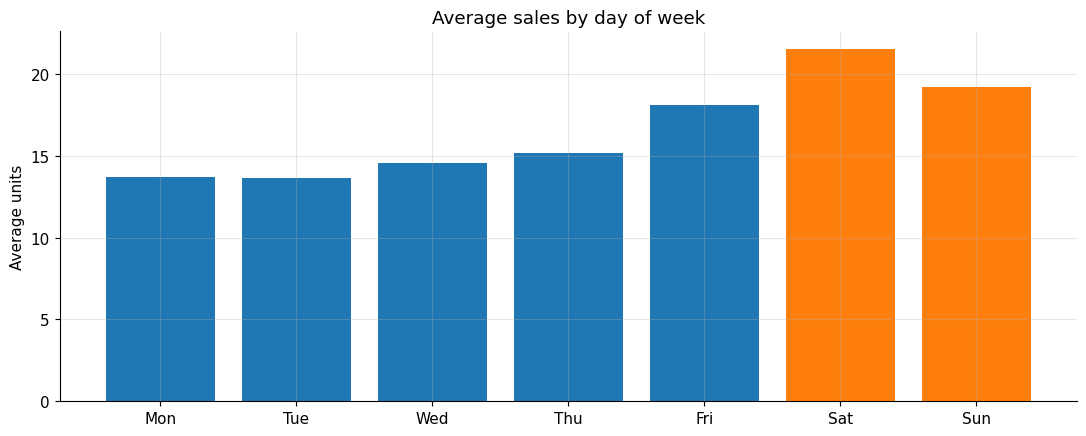

Weekends sell 135.6% of what a weekday sells (>1 = more).


In [3]:
dow = q('''
    select dow,
           avg(unit_sales_clipped) as avg_sales,
           sum(unit_sales_clipped) as total_sales
    from main_marts.fct_sales
    group by dow order by dow
''')
# In DuckDB dow: 0=Sunday..6=Saturday. Reorder to Mon..Sun for readability.
names = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",0:"Sun"}
order = [1,2,3,4,5,6,0]
dow["day"] = dow["dow"].map(names)
dow = dow.set_index("dow").loc[order].reset_index()

fig, ax = plt.subplots()
colors = [COLORS["accent"] if d in (6,0) else COLORS["primary"] for d in order]
ax.bar(dow["day"], dow["avg_sales"], color=colors)
ax.set_title("Average sales by day of week")
ax.set_ylabel("Average units")
plt.tight_layout(); plt.show()

weekend_lift = dow[dow.dow.isin([6,0])].avg_sales.mean() / dow[dow.dow.isin([1,2,3,4,5])].avg_sales.mean()
print(f"Weekends sell {weekend_lift:.1%} of what a weekday sells (>1 = more).")

**Finding → decision:** the weekly pattern is strong. Any model must capture
period-7 seasonality. This justifies the `seasonal_order` with s=7 in SARIMAX and
`weekly_seasonality` in Prophet.

## 3. Payday effect

*In Ecuador the pay cycle (15th and month-end) should lift sales.*

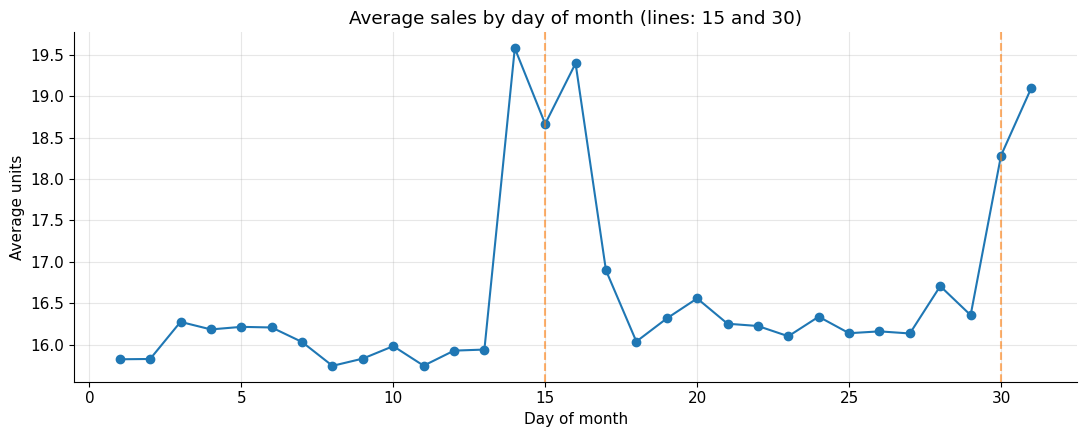

Paydays: 18.62  |  rest: 16.38  ->  lift +13.7%


In [4]:
dom = q('''
    select day_of_month, avg(unit_sales_clipped) as avg_sales
    from main_marts.fct_sales
    group by day_of_month order by day_of_month
''')
fig, ax = plt.subplots()
ax.plot(dom["day_of_month"], dom["avg_sales"], marker="o", color=COLORS["primary"])
for d in (15, 30):
    ax.axvline(d, color=COLORS["accent"], ls="--", alpha=0.6)
ax.set_title("Average sales by day of month (lines: 15 and 30)")
ax.set_xlabel("Day of month"); ax.set_ylabel("Average units")
plt.tight_layout(); plt.show()

pay = q('''select is_payday, avg(unit_sales_clipped) v from main_marts.fct_sales group by is_payday''')
r = pay.set_index("is_payday")["v"]
print(f"Paydays: {r.get(1,0):.2f}  |  rest: {r.get(0,0):.2f}  ->  lift {r.get(1,0)/r.get(0,0)-1:+.1%}")

**Finding → decision:** if the spike appears near the 15th and month-end,
`is_payday` is a strong calendar feature.

## 4. Promo lift by family

*How much does a promotion really lift sales, and does it vary by category?*

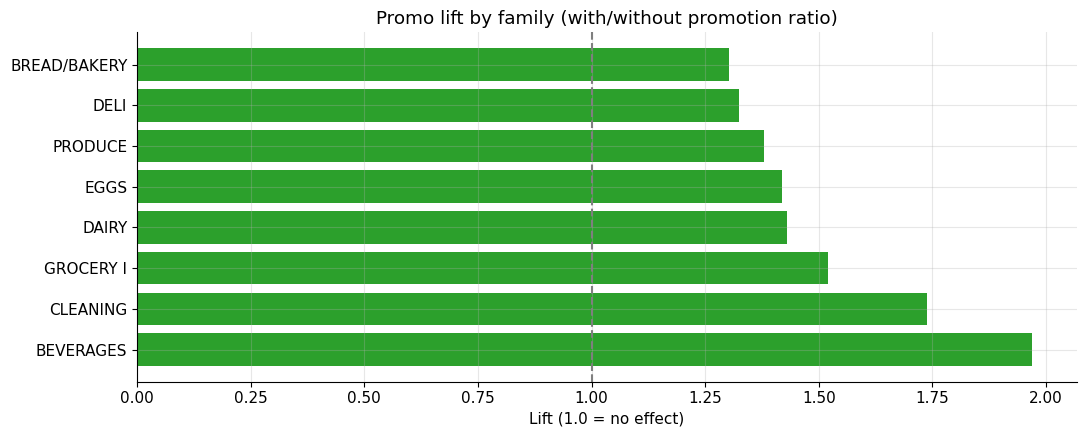

,family,without_promo,with_promo,lift
1,BEVERAGES,13.10,25.80,1.97
5,CLEANING,9.88,17.18,1.74
0,GROCERY I,21.58,32.79,1.52
3,DAIRY,11.87,16.98,1.43
7,EGGS,2.95,4.19,1.42
2,PRODUCE,15.63,21.57,1.38
6,DELI,3.97,5.26,1.33
4,BREAD/BAKERY,7.69,10.02,1.30


In [5]:
promo = q('''
    select family,
        avg(case when onpromotion then unit_sales_clipped end) as with_promo,
        avg(case when not onpromotion then unit_sales_clipped end) as without_promo
    from main_marts.fct_sales
    group by family
''')
promo["lift"] = promo["with_promo"] / promo["without_promo"]
promo = promo.sort_values("lift", ascending=False)

fig, ax = plt.subplots()
ax.barh(promo["family"], promo["lift"], color=COLORS["good"])
ax.axvline(1.0, color=COLORS["muted"], ls="--")
ax.set_title("Promo lift by family (with/without promotion ratio)")
ax.set_xlabel("Lift (1.0 = no effect)")
plt.tight_layout(); plt.show()
promo[["family","without_promo","with_promo","lift"]].round(2)

**Finding → decision:** lift varies by family. A model that ignores
`onpromotion` will systematically over- or under-forecast during promo weeks.
That's why it enters as an exogenous regressor in all three models.

## 5. ABC analysis

Already computed as a dbt model (`mart_item_abc`). We consume it directly.

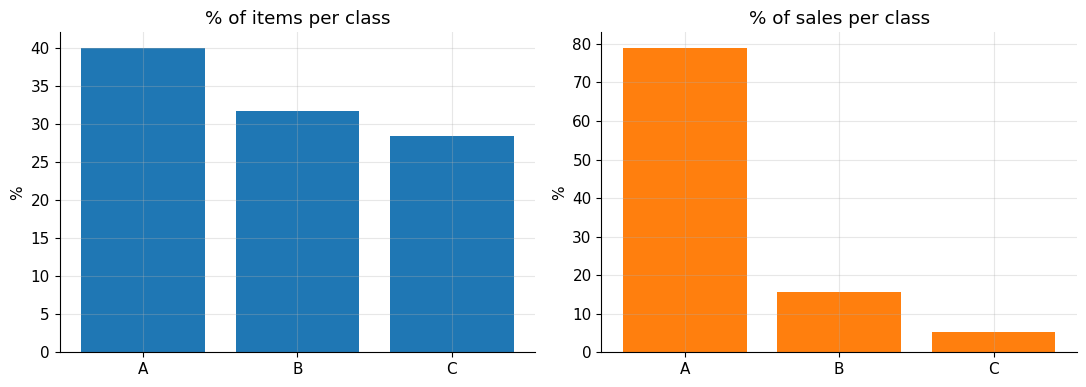

,abc_class,n_items,sales,pct_sales,pct_items
0,A,24,"1,448,675.80",79.00,40.00
1,B,19,"288,201.30",15.70,31.70
2,C,17,"96,019.80",5.20,28.30


In [6]:
abc = q('''
    select abc_class,
        count(*) as n_items,
        sum(total_sales) as sales,
        100.0*sum(total_sales)/sum(sum(total_sales)) over () as pct_sales
    from main_marts.mart_item_abc
    group by abc_class order by abc_class
''')
abc["pct_items"] = 100.0 * abc["n_items"] / abc["n_items"].sum()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(abc["abc_class"], abc["pct_items"], color=COLORS["primary"])
a1.set_title("% of items per class"); a1.set_ylabel("%")
a2.bar(abc["abc_class"], abc["pct_sales"], color=COLORS["accent"])
a2.set_title("% of sales per class"); a2.set_ylabel("%")
plt.tight_layout(); plt.show()
abc.round(1)

**Finding → decision:** Pareto concentration. Class A items carry most of the
sales, which sets **inventory prioritization**: class A gets a high service level
(98%), class C a lower one (90%). Applied in notebook 03.

## 6. Earthquake window (2016-04-16)

*A real external shock: a spike in water and supplies demand.*

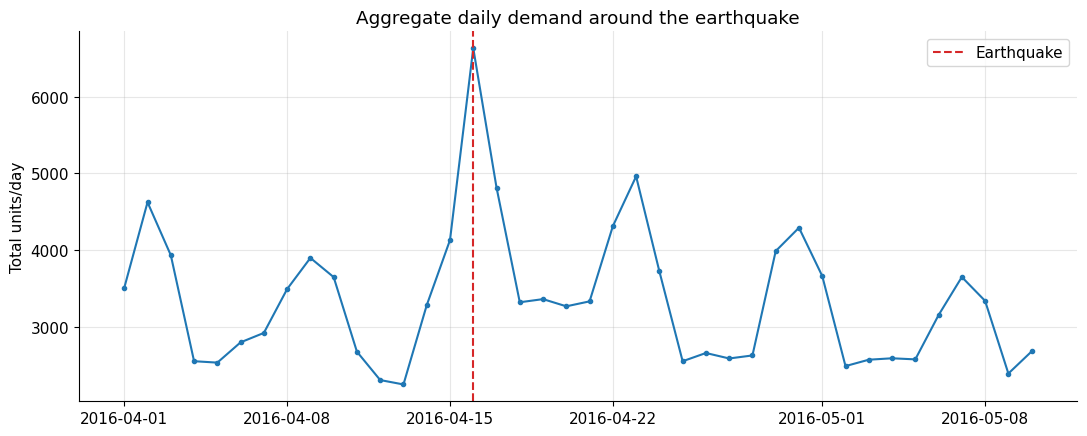

Mean before: 3,236  |  mean 2 weeks after: 3,761  ->  +16.2%


In [7]:
quake = q('''
    select date, sum(unit_sales_clipped) as total_sales
    from main_marts.fct_sales
    where date between date '2016-04-01' and date '2016-05-10'
    group by date order by date
''')
quake["date"] = pd.to_datetime(quake["date"])
fig, ax = plt.subplots()
ax.plot(quake["date"], quake["total_sales"], marker=".", color=COLORS["primary"])
ax.axvline(pd.Timestamp("2016-04-16"), color=COLORS["bad"], ls="--", label="Earthquake")
ax.set_title("Aggregate daily demand around the earthquake")
ax.set_ylabel("Total units/day"); ax.legend()
plt.tight_layout(); plt.show()

before = quake[quake.date < "2016-04-16"].total_sales.mean()
after = quake[(quake.date >= "2016-04-16") & (quake.date <= "2016-04-30")].total_sales.mean()
print(f"Mean before: {before:,.0f}  |  mean 2 weeks after: {after:,.0f}  ->  {after/before-1:+.1%}")

**Finding → decision:** an anomalous spike like this breaks any naive
forecast. Prophet handles it via changepoints; in production it would be flagged
as an event. The operative distinction is signal vs outlier: this is a real
demand event, so it belongs in the model rather than being smoothed away.

## 7. Oil–demand correlation

*Ecuador is oil-dependent: oil is a proxy for macro purchasing power.*

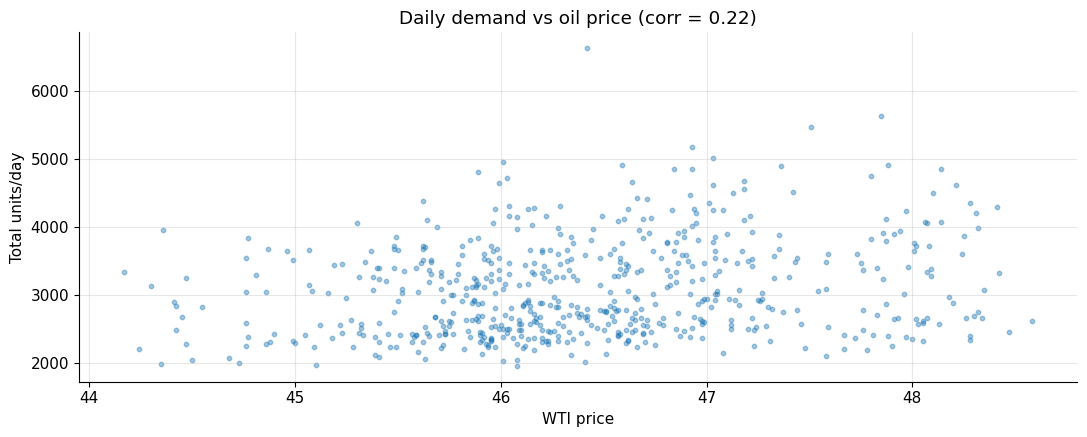

Oil–demand correlation: 0.222


In [8]:
macro = q('''
    with d as (
        select date, sum(unit_sales_clipped) as sales from main_marts.fct_sales group by date
    )
    select d.date, d.sales, o.oil_price
    from d join main_marts.dim_oil o using (date)
    where o.oil_price is not null
    order by d.date
''')
corr = macro["sales"].corr(macro["oil_price"])
fig, ax = plt.subplots()
ax.scatter(macro["oil_price"], macro["sales"], s=10, alpha=0.4, color=COLORS["primary"])
ax.set_title(f"Daily demand vs oil price (corr = {corr:.2f})")
ax.set_xlabel("WTI price"); ax.set_ylabel("Total units/day")
plt.tight_layout(); plt.show()
print(f"Oil–demand correlation: {corr:.3f}")

**Finding → decision:** the correlation is weak but non-zero, so `oil_price`
enters as a regressor. In the real data the relationship may be richer (a lagged
effect); here it is a mild contemporaneous correlation.

## 8. Perishables vs non-perishables

In [9]:
perish = q('''
    select case when perishable=1 then 'Perishable' else 'Non-perishable' end as type,
        count(distinct item_nbr) as n_items,
        avg(unit_sales_clipped) as mean_sales,
        stddev(unit_sales_clipped) as volatility
    from main_marts.fct_sales
    group by perishable
''')
perish["coef_variation"] = perish["volatility"] / perish["mean_sales"]
perish.round(2)

,type,n_items,mean_sales,volatility,coef_variation
0,Non-perishable,38,19.16,19.36,1.01
1,Perishable,22,12.46,11.62,0.93


**Finding → decision:** this table does not say what it appears to say. The CV
above is *pooled*: it mixes variation **between** items with variation **within**
each item over time. Non-perishable item means span 2.5 to 77 units/day and
perishable ones 3.2 to 28, so the pooled figure mostly reflects that difference
in item mix, not day-to-day predictability.

Measured the way the question is actually posed — CV of each item-store series
over time, then compared across the two groups — perishables come out slightly
**more** volatile: median CV 0.557 vs 0.530. That is the quantity safety stock
depends on, and the direction matches the domain expectation, although the gap is
small. The check is written out in `METHODOLOGY.md`.

The 1.25× perishable weight in NWRMSLE stays: it is the competition's official
metric, and the operational asymmetry holds on its own (an over-ordered
perishable is thrown away, not carried into next week).

---

## Summary of findings

| Signal | Finding | Consequence for the model/business |
|---|---|---|
| Weekly seasonality | Weekends higher | Period-7 seasonality mandatory |
| Payday | Spike near 15th and month-end | `is_payday` feature |
| Promo lift | Varies by family | `onpromotion` as a regressor |
| ABC | Few items → most of sales | Differentiated service level |
| Earthquake | Anomalous spike April 2016 | Changepoints / event flag |
| Oil | Macro correlation | `oil_price` as a regressor |
| Perishables | Pooled CV is confounded by item mix; within-series CV 0.56 vs 0.53 | 1.25 weight kept; the volatility gap is real but small |

**Next step:** `02_forecasting.ipynb` — build the models that capture these
signals and validate which one predicts best with temporal backtesting.
